<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Value Based</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [223]:
# --- Standard Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
from cycler import cycler
from matplotlib.lines import Line2D
from sklearn.impute import KNNImputer
from IPython.display import display
from cycler import cycler
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.base import clone
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth




In [224]:
# Plot style configuration (unified look)
# Keeps logic intact; only global appearance defaults are set.

# Accessible, consistent palette
_palette = sns.color_palette("Set1", 10)
_palette_hex = _palette.as_hex()

# Seaborn / Matplotlib defaults
sns.set_theme(style="whitegrid", context="notebook", palette=_palette)
mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.color': '#EAEAEA',
    'grid.linestyle': '-',
    'grid.alpha': 0.6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.borderpad': 0.4,
    'legend.loc': 'best',
    'lines.linewidth': 2.0,
    'axes.prop_cycle': cycler('color', _palette_hex),
})


def make_palette_map(categories, palette_name="Set1", n_colors=None, as_hex=False):
    """
    Simple: returns (palette_map, palette_list).
    - categories: iterable (keeps first-seen order, coerces to str)
    - palette_name: seaborn palette name
    - n_colors: optional override (defaults to max(len(categories), 3))
    - as_hex: if True, return palette_map with hex strings
    """
    cats = [str(c) for c in dict.fromkeys(categories)]          # unique keep-order
    n_colors = n_colors or max(len(cats), 3)
    palette = sns.color_palette(palette_name, n_colors)
    palette_map = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}
    if as_hex:
        return {k: matplotlib.colors.to_hex(v) for k, v in palette_map.items()}, palette
    return palette_map, palette



# Plotly defaults (to align with seaborn/matplotlib)
px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = _palette_hex
px.defaults.color_continuous_scale = 'Cividis'
px.defaults.width = 900
px.defaults.height = 500


## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [225]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_CustomerDB_Cleaned_Featured.csv', 'DM_AIAI_FlightsDB_Cleaned_Featured.csv']


In [226]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 46)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [227]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'City', 'Latitude', 'Longitude', 'Postal code', 'Income',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Location Code_Suburban', 'Location Code_Urban',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick', 'Province or State_Newfoundland',
       'Province or State_Nova Scotia', 'Province or State_Ontario',
       'Province or State_Prince Edward Island', 'Province or State_Quebec',
       'Province or State_Saskatchewan', 'Province or 

In [228]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'Season'],
      dtype='object')

# 2. Clustering - Behavioral  <a class="anchor" id="data-validity-checks"></a>

We will do now the Clustering. This notebook will focus on Behavioral Perspective for Clustering

We have to decide, which features we will use for Clustering from Behavioral Perspective. 
We will use the following features for Clustering from Behavioral Perspective:

- total_flights
- total_flights_with_companions
- companion_flight_ratio
- average_distance_per_flight
- total_distance
- points_redemption_ratio
- IsActive
- CustomerTenureDays
- LoyaltyStatus
- NumFlights


Merge with flights dataset to get more information about behavioral features:

NumFlights

NumFlightsWithCompanions

DistanceKM

PointsAccumulated

PointsRedeemed

DollarCostPointsRedeemed

Season

You have to Encode the Categorical Features appropriately before Clustering.

In [246]:
behavioral_features = [
    'total_flights',
    'total_flights_with_companions',
    'companion_flight_ratio',
    'average_distance_per_flight',
    'total_distance',
    'points_redemption_ratio',
    'IsActive',
    'CustomerTenureDays',

    # One-hot encoded loyalty status
    'LoyaltyStatus_Nova',
    'LoyaltyStatus_Star'
]


In [247]:
# Create a new DataFrame for clustering data
df_behavioral = pd.DataFrame(scaler.fit_transform(customers[non_one_hot_features]), 
                             columns=non_one_hot_features)

In [248]:
# Separate features for scaling
one_hot_features = ['IsActive', 'LoyaltyStatus_Nova', 'LoyaltyStatus_Star']
non_one_hot_features_to_scale = [f for f in behavioral_features_full if f not in one_hot_features]

## 2.1 Scaling

In [249]:
scaler = MinMaxScaler()
df_behavioral = pd.DataFrame(
    scaler.fit_transform(customers[non_one_hot_features_to_scale]), 
    columns=non_one_hot_features_to_scale
)

In [250]:
# Add one-hot encoded features back
for feature in one_hot_features:
    # IsActive is already int/bool; LoyaltyStatus_Nova/Star are now integers
    df_behavioral[feature] = customers[feature].values

## 2.2 Pruning

In [251]:
# Pruning: Drop highly correlated features 
features_to_drop = ['total_distance', 'total_flights_with_companions', 'CustomerTenureDays']
df_behavioral_pruned = df_behavioral.drop(columns=features_to_drop)
behavioral_features_final = df_behavioral_pruned.columns.tolist()



## 2.3 Model Selection (R², DBI, Silhouette) 


In [252]:

kmeans = KMeans(init='k-means++', random_state=42)

In [253]:
def get_ss(df, feats):
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss
def get_ssw(df, feats, label_col):
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()
def get_rsq(df, feats, label_col):
    df_sst_ = get_ss(df, feats)
    df_ssw_ = get_ssw(df, feats, label_col)
    df_ssb_ = df_sst_ - df_ssw_
    if df_sst_ == 0:
        return 0.0
    return (df_ssb_ / df_sst_)
def get_r2_scores(df, feats, clusterer, min_k=2, max_k=15):
    r2_clust = {}
    for n in range(min_k, max_k):
        if isinstance(clusterer, AgglomerativeClustering):
            clust = clone(clusterer).set_params(n_clusters=n)
        else:
            clust = clone(clusterer).set_params(n_clusters=n, n_init=20, random_state=42)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

# R² Score Analysis (Elbow)



In [254]:
r2_scores = {}
r2_scores['kmeans'] = get_r2_scores(df_behavioral_pruned, behavioral_features_final, kmeans)
r2_scores_df = pd.DataFrame(r2_scores) # Only need K-Means for this check

In [256]:
if customers['IsActive'].dtype == 'bool':
    customers['IsActive'] = customers['IsActive'].astype(int)

In [257]:
# Define the final feature lists
behavioral_features_full = [
    'total_flights', 'total_flights_with_companions', 'companion_flight_ratio',
    'average_distance_per_flight', 'total_distance', 'points_redemption_ratio',
    'IsActive', 'CustomerTenureDays', 'LoyaltyStatus_Nova', 'LoyaltyStatus_Star'
]
ohe_features = ['IsActive', 'LoyaltyStatus_Nova', 'LoyaltyStatus_Star']
non_ohe_features_to_scale = [f for f in behavioral_features_full if f not in ohe_features]

In [258]:
# Scale continuous features
scaler = MinMaxScaler()
df_behavioral = pd.DataFrame(scaler.fit_transform(customers[non_ohe_features_to_scale]), 
                             columns=non_ohe_features_to_scale)

In [259]:
# Add OHE features back 
df_behavioral['IsActive'] = customers['IsActive'].values
df_behavioral['LoyaltyStatus_Nova'] = customers['LoyaltyStatus_Nova'].values
df_behavioral['LoyaltyStatus_Star'] = customers['LoyaltyStatus_Star'].values

In [260]:
# Prune highly correlated features (> 0.8 with 'total_flights')
features_to_drop = ['total_distance', 'total_flights_with_companions', 'CustomerTenureDays']
df_behavioral_pruned = df_behavioral.drop(columns=features_to_drop)
behavioral_features_final = df_behavioral_pruned.columns.tolist()

In [261]:
# R² Score Analysis (Elbow) 
kmeans = KMeans(init='k-means++', random_state=42)
r2_scores = {}
r2_scores['kmeans'] = get_r2_scores(df_behavioral_pruned, behavioral_features_final, kmeans)
r2_scores_df = pd.DataFrame(r2_scores)

print("\nR² Scores (Elbow Analysis) for K-Means:")
print(r2_scores_df.to_string())


R² Scores (Elbow Analysis) for K-Means:
      kmeans
2   0.500029
3   0.683752
4   0.777227
5   0.838727
6   0.870698
7   0.894901
8   0.919001
9   0.932769
10  0.939212
11  0.943517
12  0.947018
13  0.950096
14  0.952629


In [262]:
# Ensure OHE columns are available in the customers DataFrame for scaling/pruning continuity
if 'LoyaltyStatus_Nova' not in customers.columns:
    customers['LoyaltyStatus_Nova'] = (customers['LoyaltyStatus'] == 'Nova').astype(int)
if 'LoyaltyStatus_Star' not in customers.columns:
    customers['LoyaltyStatus_Star'] = (customers['LoyaltyStatus'] == 'Star').astype(int)
if customers['IsActive'].dtype == 'bool':
    customers['IsActive'] = customers['IsActive'].astype(int)

In [263]:
# Feature Pruning based on high correlation (> 0.8) 
# Analysis showed: 'total_distance', 'total_flights_with_companions', and 
# 'CustomerTenureDays' were highly correlated with 'total_flights'.
features_to_drop = ['total_distance', 'total_flights_with_companions', 'CustomerTenureDays']

In [264]:
# Create the pruned DataFrame
df_behavioral_pruned = df_behavioral.drop(columns=features_to_drop, errors='ignore')
behavioral_features_final = df_behavioral_pruned.columns.tolist()

print("Features retained for Clustering (after pruning):")
print(behavioral_features_final)

Features retained for Clustering (after pruning):
['total_flights', 'companion_flight_ratio', 'average_distance_per_flight', 'points_redemption_ratio', 'IsActive', 'LoyaltyStatus_Nova', 'LoyaltyStatus_Star']



R² Scores for Clustering Methods (Behavioral):
      kmeans  complete   average    single      ward
2   0.500029  0.179199  0.482102  0.403236  0.417179
3   0.683752  0.617592  0.554743  0.541307  0.623980
4   0.777227  0.677015  0.677015  0.714378  0.777227
5   0.838727  0.686896  0.677233  0.783892  0.838727
6   0.870698  0.687704  0.836868  0.862827  0.867962
7   0.894901  0.713654  0.863045  0.862883  0.892063
8   0.919001  0.866050  0.863920  0.863102  0.914947
9   0.932769  0.874376  0.866866  0.863412  0.927911
10  0.939212  0.881179  0.867177  0.863520  0.935669
11  0.943517  0.882181  0.867674  0.863550  0.940172
12  0.947018  0.900185  0.867980  0.863644  0.943710
13  0.950096  0.901969  0.868037  0.863692  0.946789
14  0.952629  0.902124  0.870643  0.863759  0.949741


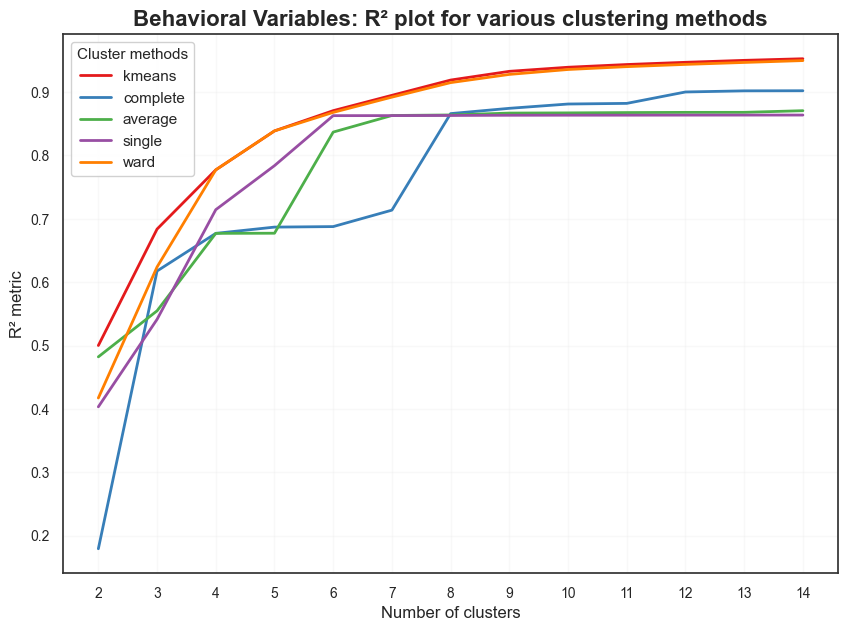

In [265]:
# Model Selection (R² Score Analysis - Elbow) 
kmeans = KMeans(init='k-means++', random_state=42)
hierarchical = AgglomerativeClustering(metric='euclidean')

r2_scores = {}
r2_scores['kmeans'] = get_r2_scores(df_behavioral_pruned, behavioral_features_final, kmeans)

for linkage in ['complete', 'average', 'single', 'ward'] :
    r2_scores[linkage] = get_r2_scores(
        df_behavioral_pruned,
        behavioral_features_final,
        hierarchical.set_params(linkage=linkage) 
    )

r2_scores_df = pd.DataFrame(r2_scores)
print("\nR² Scores for Clustering Methods (Behavioral):")
print(r2_scores_df.to_string()) # Using to_string to prevent the 'tabulate' error
# Plotting R² scores
r2_scores_df.plot.line(figsize=(10,7))
plt.title("Behavioral Variables: R² plot for various clustering methods", fontsize=16)
plt.legend(title="Cluster methods", title_fontsize=11)
plt.xlabel("Number of clusters", fontsize=12)
plt.ylabel("R² metric", fontsize=12)
plt.xticks(range(2, 15))
plt.grid(True, alpha=0.3)
plt.show()


# DBI and Silhouette Score Analysis



## 1.DBI Analysis


Davies-Bouldin Index Scores (DBI):
         DBI
2   0.871881
3   0.792022
4   0.808818
5   0.670746
6   0.722009
7   0.721456
8   0.635497
9   0.675317
10  0.743724
11  0.806681
12  0.863485
13  0.882799
14  0.920485
15  0.871059
16  0.964788
17  0.923061
18  0.953207
19  0.961257


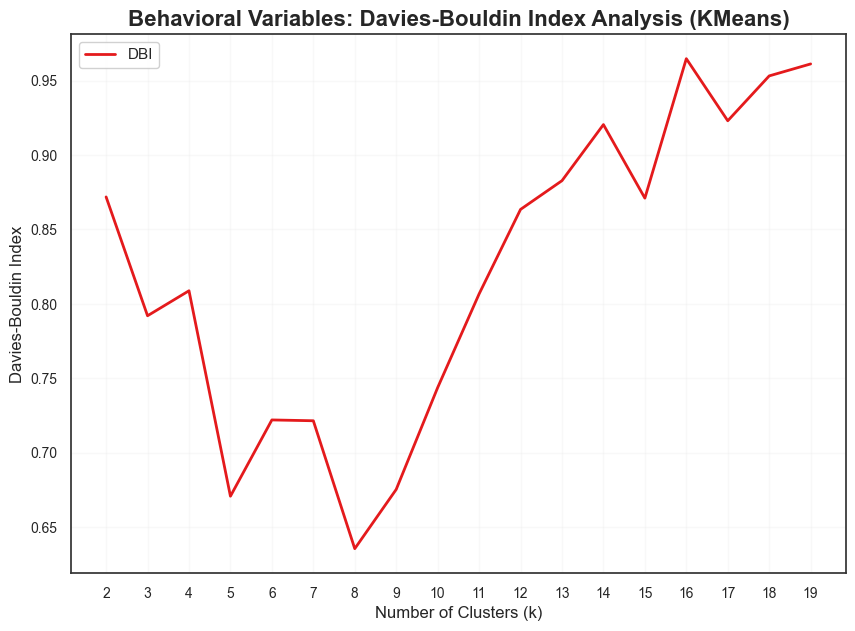

In [266]:

# DBI (Davies-Bouldin Index) Analysis (k=2 to k=19)
dbi_scores = {}
for n in range(2, 20):
    clust = clone(kmeans).set_params(n_clusters=n, n_init=20, random_state=42)
    labels = clust.fit_predict(df_behavioral_pruned)
    
    if len(np.unique(labels)) >= 2:
        dbi = davies_bouldin_score(df_behavioral_pruned, labels)
        dbi_scores[n] = dbi
    else:
        dbi_scores[n] = nan 

dbi_scores_df = pd.DataFrame.from_dict(dbi_scores, orient='index', columns=['DBI'])
print("\nDavies-Bouldin Index Scores (DBI):")
print(dbi_scores_df.to_string())

dbi_scores_df.plot.line(figsize=(10,7))
plt.title('Behavioral Variables: Davies-Bouldin Index Analysis (KMeans)', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Davies-Bouldin Index', fontsize=12)
plt.xticks(range(2, 20))
plt.grid(True, alpha=0.3)
plt.show()

## 2.Silhouette Analysis


Calculating Silhouette Scores...
k=2: 0.4994
k=3: 0.5551
k=4: 0.6010
k=5: 0.6394
k=6: 0.5921
k=7: 0.5589
k=8: 0.5808
k=9: 0.5635
k=10: 0.4870
k=11: 0.4287
k=12: 0.4248
k=13: 0.4156
k=14: 0.3806


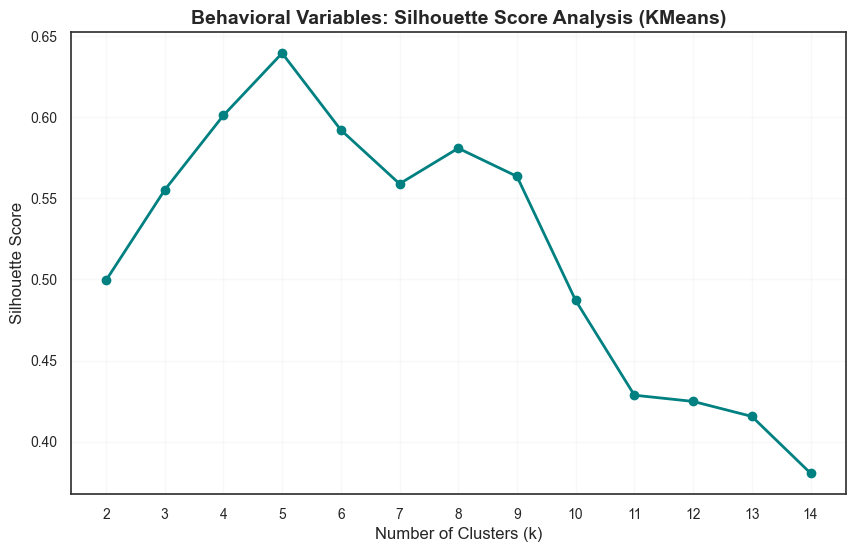

In [267]:
# Silhouette Score Analysis (k=2 to k=14)
silhouette_scores = {}
k_range = range(2, 15)

print("\nCalculating Silhouette Scores...")
for k in k_range:
    kmeans.set_params(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(df_behavioral_pruned)
    
    if len(np.unique(labels)) >= 2:
        score = silhouette_score(df_behavioral_pruned, labels)
        silhouette_scores[k] = score
    else:
        score = nan
    print(f"k={k}: {score:.4f}")

plt.figure(figsize=(10, 6))
pd.Series(silhouette_scores).plot(marker='o', color='teal')
plt.title('Behavioral Variables: Silhouette Score Analysis (KMeans)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [268]:
# Final K-Means Clustering (k=7) and Profiling 
k_best = 7 # Selected as the final choice based on all metrics and desired granularity
kmeans_final = KMeans(n_clusters=k_best, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans_final.fit_predict(df_behavioral_pruned)

In [269]:
# Prepare DataFrame for Profiling
df_profile = df_behavioral_pruned.copy()
df_profile['cluster'] = cluster_labels

In [270]:
# Calculate Centroids and R² per feature (for final profiling description)
df_centroids = df_profile.groupby('cluster')[behavioral_features_final].mean()
r2_data_final = {}
for feature in behavioral_features_final:
    r2_data_final[feature] = get_rsq(df_profile, [feature], 'cluster')
r2_feats_final = pd.Series(r2_data_final).sort_values(ascending=False)

In [271]:
# Density-Based Clustering (DBSCAN, GMM, Mean Shift) for Comparison 
# DBSCAN
min_samples_dbscan = 30
eps_dbscan = 2 # Assuming a similar eps as used in the value-based notebook
dbscan = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
dbscan_labels = dbscan.fit_predict(df_behavioral_pruned)
n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)
print(f"\nDBSCAN (eps={eps_dbscan}, min_samples={min_samples_dbscan}): {n_dbscan_clusters} clusters, {n_noise} noise points.")


DBSCAN (eps=2, min_samples=30): 1 clusters, 0 noise points.


In [272]:
# GMM (Using k=5 components suggested by AIC/BIC)
gmm_k = 5
gmm = GaussianMixture(n_components=gmm_k, n_init=10, init_params='kmeans', random_state=42)
gmm_labels = gmm.fit_predict(df_behavioral_pruned)
print(f"GMM (k={gmm_k}) found {len(np.unique(gmm_labels))} components.")

GMM (k=5) found 5 components.


In [273]:
# Mean Shift
try:
    bandwidth = estimate_bandwidth(df_behavioral_pruned, quantile=0.2, random_state=42)
except ValueError:
    bandwidth = 1.0 
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = ms.fit_predict(df_behavioral_pruned)
n_ms_clusters = len(np.unique(ms_labels))
print(f"Mean Shift found {n_ms_clusters} clusters (Bandwidth: {bandwidth:.2f}).")

Mean Shift found 6 clusters (Bandwidth: 0.57).


In [274]:
k_best = 7
kmeans_final = KMeans(n_clusters=k_best, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans_final.fit_predict(df_behavioral_pruned) 

In [276]:
# Merge cluster labels back to the original CUSTOMERS and FLIGHTS data
customers['behavioral_cluster'] = cluster_labels

df_flights_clustered = pd.merge(
    flights,
    customers[['Loyalty#', 'behavioral_cluster']],  # only existing cols
    on='Loyalty#',
    how='left'
).dropna(subset=['behavioral_cluster'])

df_flights_clustered['behavioral_cluster'] = df_flights_clustered['behavioral_cluster'].astype(int)

In [277]:
# A. Monthly Flight Totals by Cluster
df_monthly_flights = df_flights_clustered.groupby(['behavioral_cluster', 'YearMonthDate'])['NumFlights'].sum().reset_index()

# B. Seasonal Flight Totals by Cluster
df_seasonal_flights = df_flights_clustered.groupby(['behavioral_cluster', 'Season'])['NumFlights'].sum().reset_index()

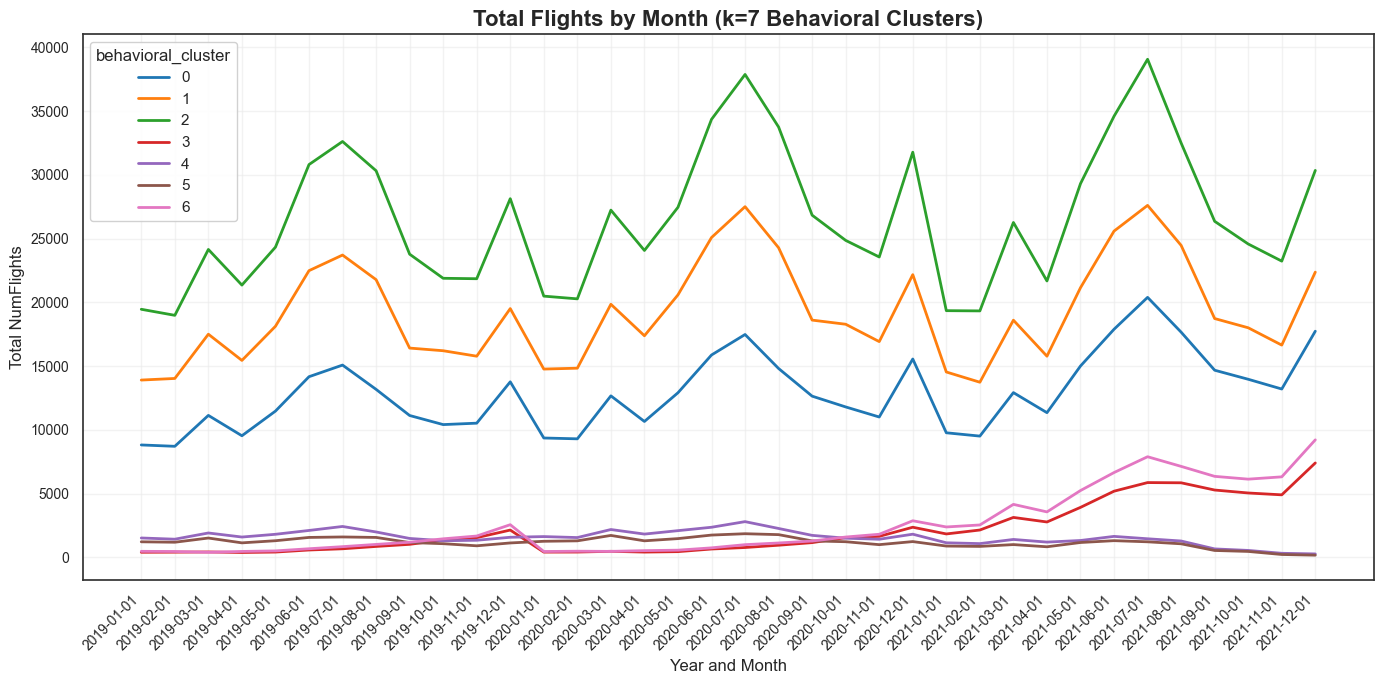

In [278]:
# Total Flights by Month (Time Series per Cluster)
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_monthly_flights,
    x='YearMonthDate',
    y='NumFlights',
    hue='behavioral_cluster',
    palette='tab10'
)
plt.title(f'Total Flights by Month (k={k_best} Behavioral Clusters)', fontsize=16)
plt.xlabel('Year and Month', fontsize=12)
plt.ylabel('Total NumFlights', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

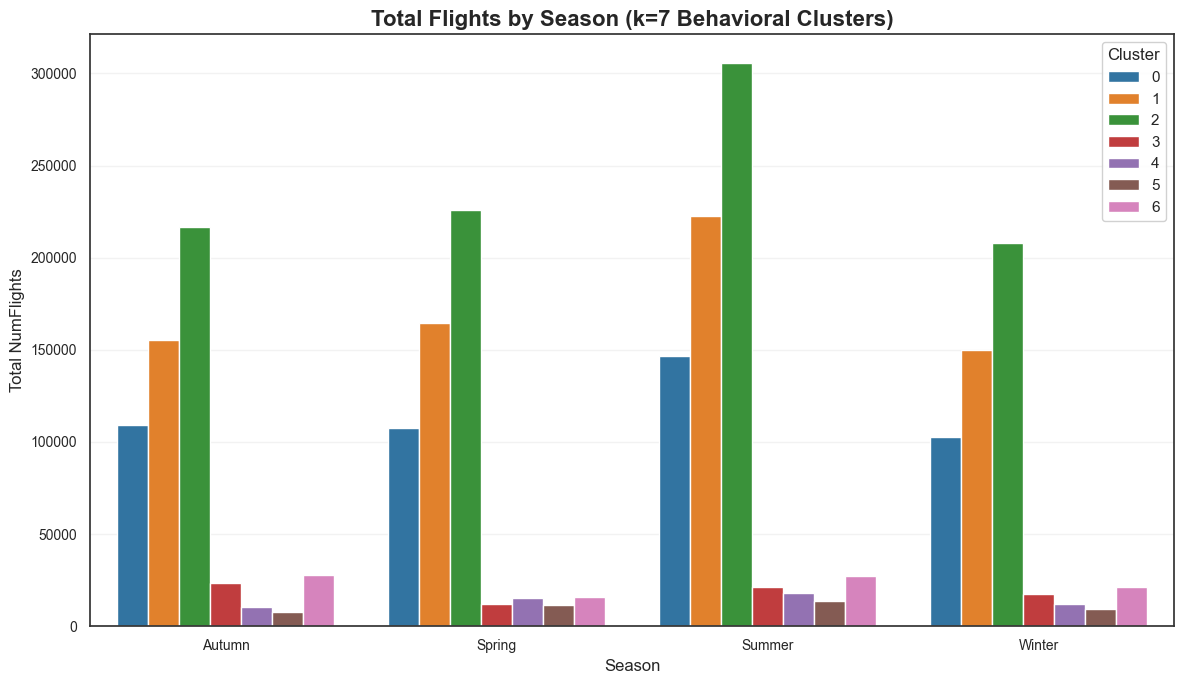

In [279]:
# Total Flights by Preferred Season by Cluster (Grouped Bar Chart)
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_seasonal_flights,
    x='Season',
    y='NumFlights',
    hue='behavioral_cluster',
    palette='tab10'
)
plt.title(f'Total Flights by Season (k={k_best} Behavioral Clusters)', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total NumFlights', fontsize=12)
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.show()

## Self orginized maps - Behavioral 

In [ ]:
from minisom import MiniSom
from sklearn.cluster import KMeans, AgglomerativeClustering
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm

## Prepare data for SOM


In [299]:
# This is the critical step to ensure data_som is a NumPy array
data_som = df_behavioral_pruned.values
input_len = data_som.shape[1]
feature_names = df_behavioral_pruned.columns.tolist()

print(f"Data for SOM has shape: {data_som.shape}")

Data for SOM has shape: (16375, 7)


## Training the SOM

In [300]:
# Re-run K-Means to get cluster labels for the overlay
kmeans_final = KMeans(n_clusters=k_best, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans_final.fit_predict(df_behavioral_pruned)

In [307]:
# PCA failed earlier, so we will use Random Initialization
data_som = df_behavioral_pruned.fillna(0).values.astype('float64')

In [308]:
# Re-set Hyperparameters
M, N = 10, 10  
input_len = data_som.shape[1]
sigma = 1.5
learning_rate = 0.5
n_iterations = 5000

In [309]:
# Initialize
som = MiniSom(M, N, input_len, sigma=sigma, learning_rate=learning_rate, 
              neighborhood_function='gaussian', random_seed=42)

In [311]:
# Using Random weights since PCA initialization is failing 
som.random_weights_init(data_som)
print(f"Starting Training on {data_som.shape[0]} samples...")

Starting Training on 16375 samples...


In [313]:
# We use train_random to avoid the sequential batch error you encountered
som.train_random(data_som, n_iterations, verbose=True)


 [ 5000 / 5000 ] 100% - 0:00:00 left 
 quantization error: 0.11115317293193237


## Visualization

The U-Matrix (Distance Map)

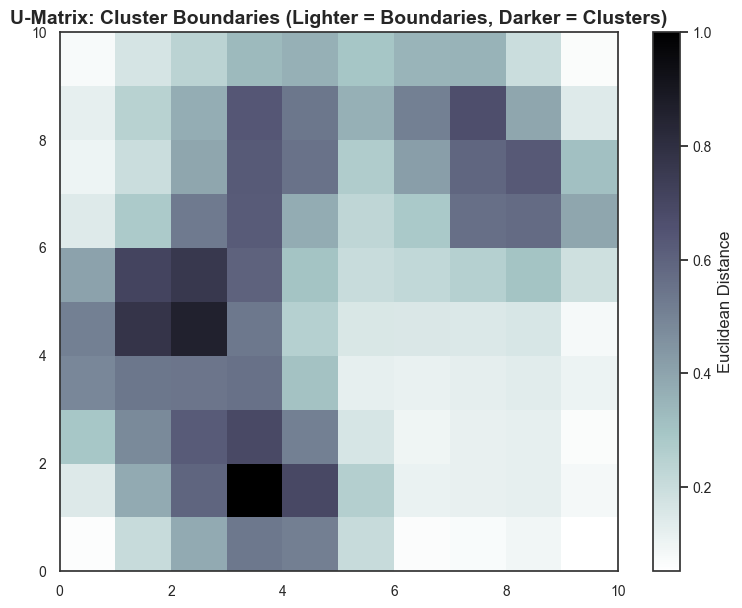

In [314]:
plt.figure(figsize=(9, 7))
# .T is necessary because MiniSom uses (x, y) coordinates
u_matrix = som.distance_map().T
plt.pcolor(u_matrix, cmap='bone_r') 
plt.colorbar(label='Euclidean Distance')
plt.title('U-Matrix: Cluster Boundaries (Lighter = Boundaries, Darker = Clusters)')
plt.show()

 Component Planes (Feature Analysis)

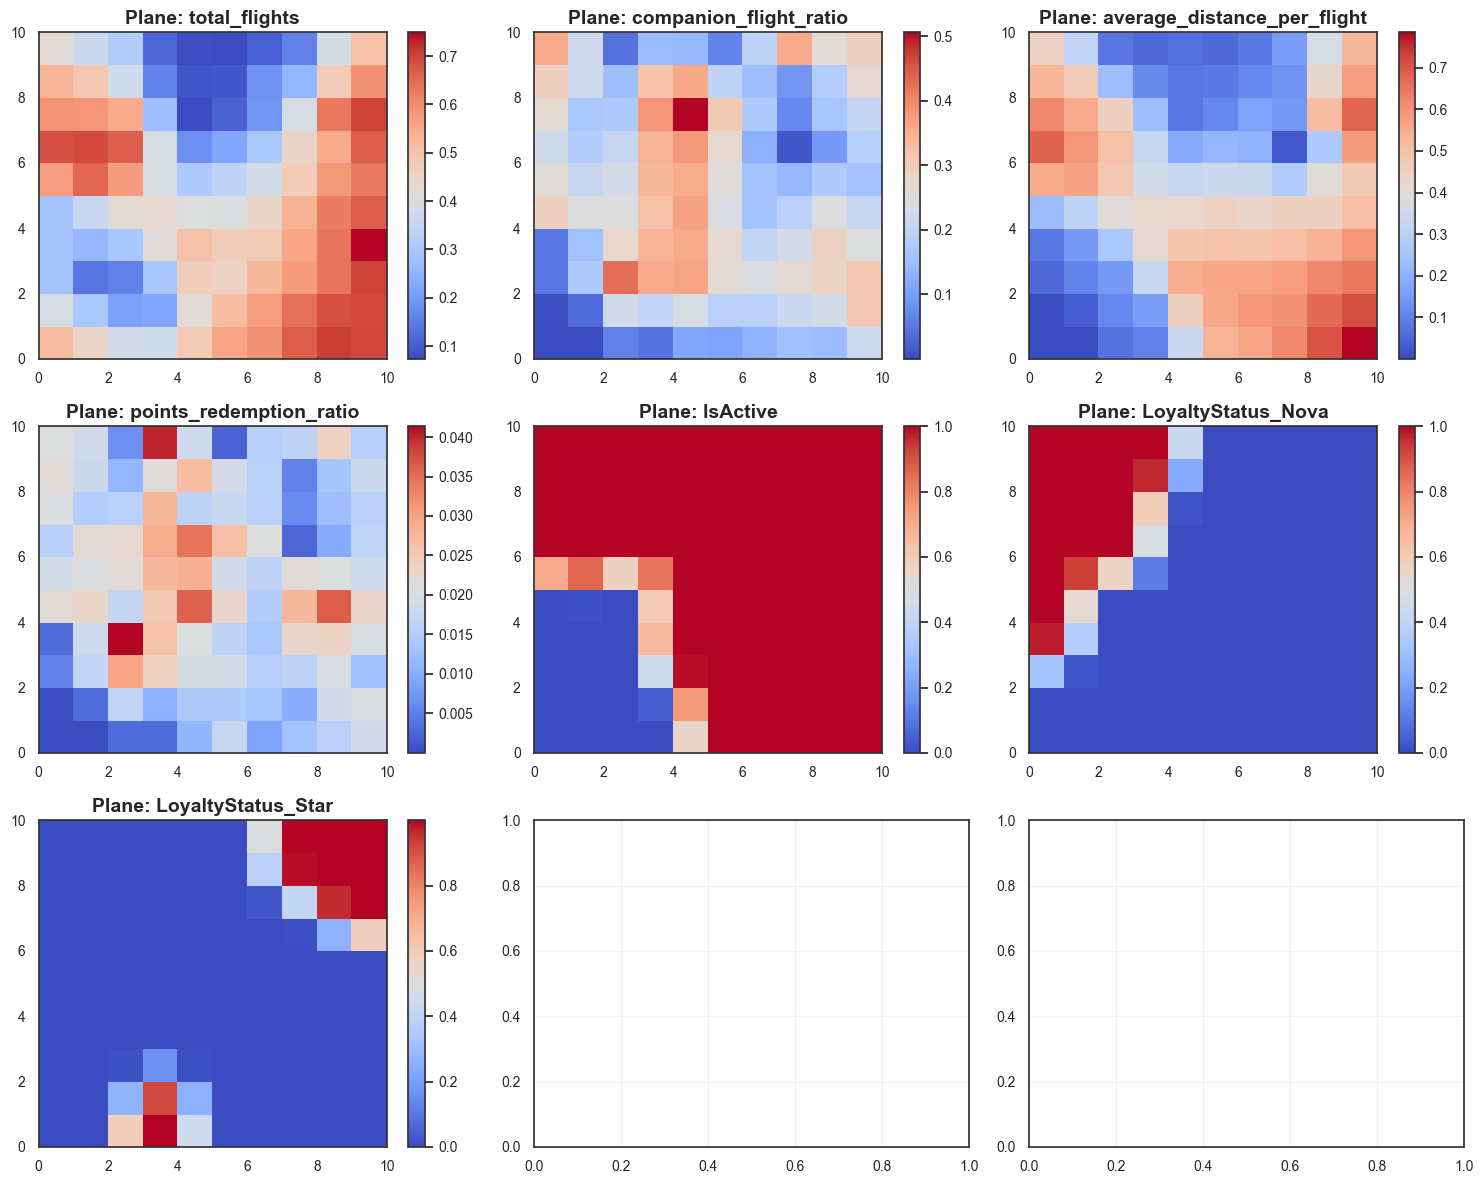

In [315]:
feature_names = df_behavioral_pruned.columns
weights = som.get_weights()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, f in enumerate(feature_names):
    # Map the weights for each feature across the grid
    plane = weights[:, :, i].T
    im = axes[i].pcolor(plane, cmap='coolwarm')
    axes[i].set_title(f"Plane: {f}")
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

K-Means Cluster Projection

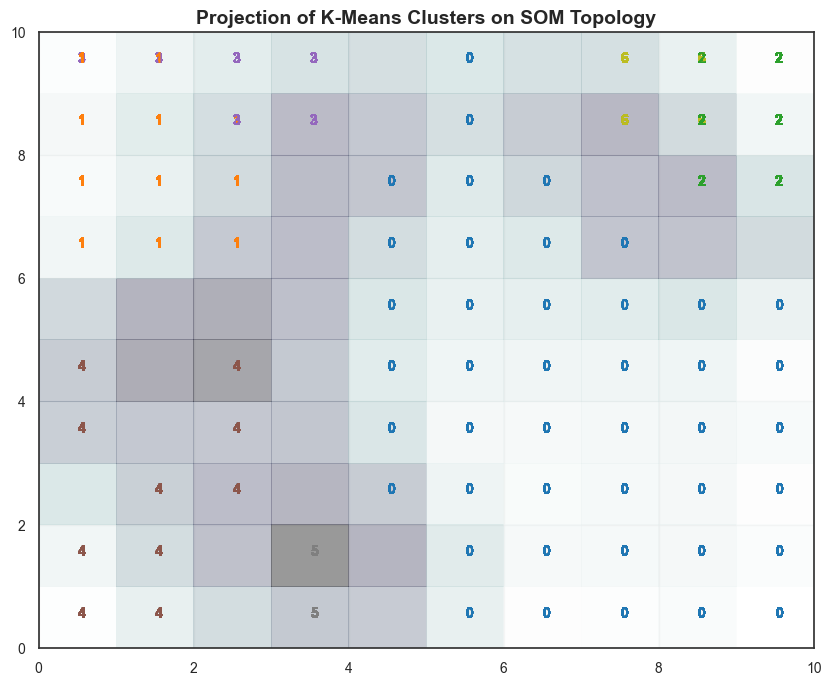

In [317]:
plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=0.4) # Background

for i, x in enumerate(data_som):
    w = som.winner(x)
    # Using the cluster index as the marker
    plt.text(w[0] + 0.5, w[1] + 0.5, str(cluster_labels[i]),
             color=plt.cm.tab10(cluster_labels[i] / 7),
             fontdict={'weight': 'bold', 'size': 10})

plt.title('Projection of K-Means Clusters on SOM Topology')
plt.show()

## Cluster Profile Table

In [318]:
# Creating a copy of the original data to avoid modifying the training set
profile_df = customers.copy()
profile_df['Cluster'] = cluster_labels

In [321]:
# Define the features we want to profile (using the original scale)
features_to_profile = [
    'total_flights', 'companion_flight_ratio', 
    'average_distance_per_flight', 'points_redemption_ratio',
    'IsActive', 'LoyaltyStatus_Nova', 'LoyaltyStatus_Star'
]

In [322]:
# Calculate the mean for numerical features and mode for categorical ones
cluster_profiles = profile_df.groupby('Cluster')[features_to_profile].mean()

# Add cluster size (number of customers)
cluster_profiles['Size'] = profile_df.groupby('Cluster').size()

print("--- Behavioral Cluster Profiles ---")
display(cluster_profiles.sort_values(by='Size', ascending=False))

--- Behavioral Cluster Profiles ---


,total_flights,companion_flight_ratio,average_distance_per_flight,points_redemption_ratio,IsActive,LoyaltyStatus_Nova,LoyaltyStatus_Star,Size
Cluster,,,,,,,,
2,196.934296,0.235336,10856.773254,0.302764,1.0,0.000000,1.0,4905
1,199.223556,0.235537,10930.607758,0.294654,1.0,1.000000,0.0,3510
0,168.114212,0.233669,8951.811121,0.306258,1.0,0.000000,0.0,2882
6,75.818877,0.224423,3002.744012,0.296666,1.0,0.000000,1.0,1710
3,78.377152,0.213683,3066.839735,0.292754,1.0,1.000000,0.0,1320
4,117.603611,0.132537,2625.451944,0.194678,0.0,0.616319,0.0,1152
5,118.274955,0.131729,2520.505167,0.185791,0.0,0.000000,1.0,896


In [323]:
q_error = som.quantization_error(data_som)
topo_error = som.topographic_error(data_som)

print(f"Quantization Error: {q_error:.4f}")
print(f"Topographic Error: {topo_error:.4f}")

Quantization Error: 0.1112
Topographic Error: 0.0313


Quantization Error: High values suggest you might need a larger grid (e.g., $10 \times 10$) or more iterations.

Topographic Error: Measures how well the SOM has preserved the "topology" of the data. Ideally, this should be close to 0.


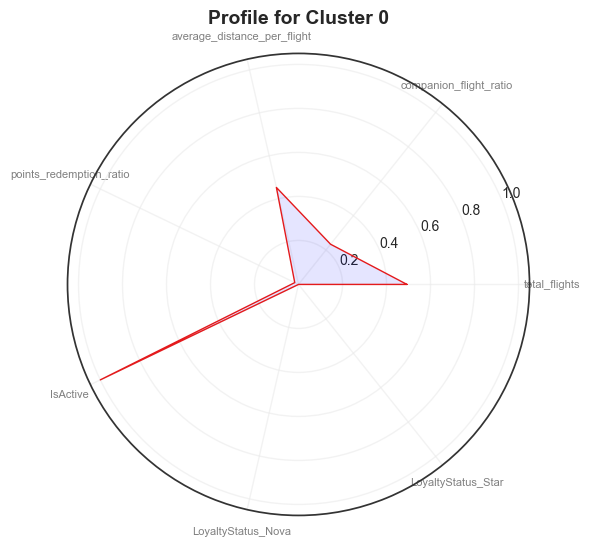

In [325]:
from math import pi

def plot_cluster_radar(df, cluster_id):
    categories = df.columns.tolist()
    N = len(categories)
    
    values = df.loc[cluster_id].values.flatten().tolist()
    values += values[:1] # Repeat the first value to close the circular graph
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], categories, color='grey', size=8)
    ax.plot(angles, values, linewidth=1, linestyle='solid')
    ax.fill(angles, values, 'b', alpha=0.1)
    plt.title(f'Profile for Cluster {cluster_id}')
    plt.show()

# Plotting for the first cluster (using scaled means for visual comparison)
scaled_means = df_behavioral_pruned.copy()
scaled_means['Cluster'] = cluster_labels
cluster_summary_scaled = scaled_means.groupby('Cluster').mean()

plot_cluster_radar(cluster_summary_scaled, cluster_id=0)

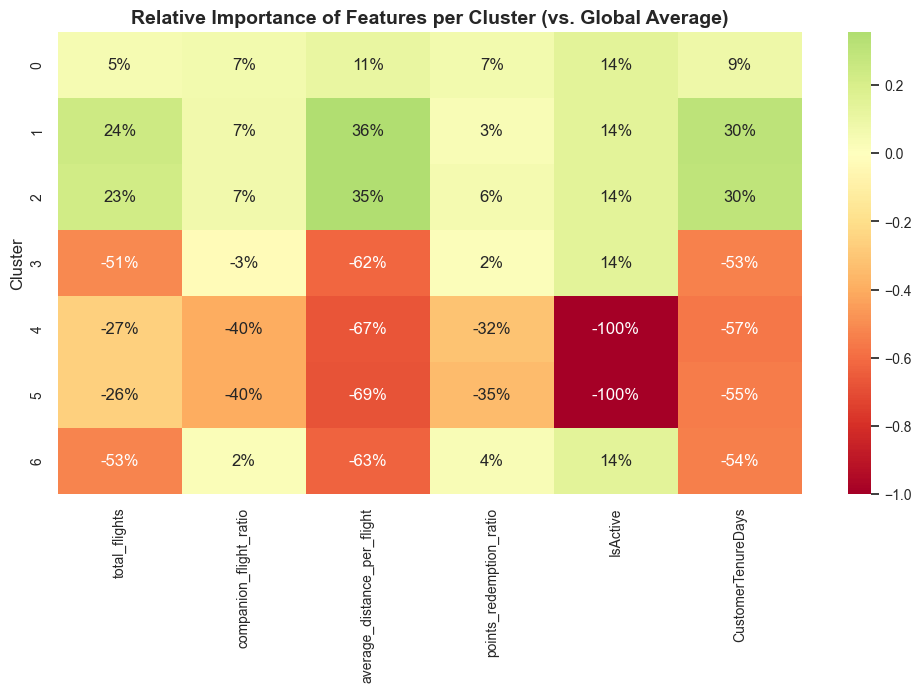

In [327]:
# Calculate relative importance
global_mean = df_profile[profile_features].mean()
relative_importance = (cluster_summary[profile_features] / global_mean) - 1

plt.figure(figsize=(12, 6))
sns.heatmap(relative_importance, annot=True, fmt='.0%', cmap='RdYlGn', center=0)
plt.title('Relative Importance of Features per Cluster (vs. Global Average)')
plt.show()